# Orbital environment

## Initialize

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

In [2]:
from math import radians, pi, sin
import matplotlib.pyplot as plt
from tqdm.auto import trange
import numba as nb
import numpy as np
from numba.experimental import jitclass
from IPython.display import display, JSON

from cw.context import time_it
from cw.filters import smooth_signal

from traj2.logger import Logger

from environment import LauncherV1Orbital, Stage, AP_NONE, AP_PITCH_CONTROL, AP_FLIGHT_PATH_CONTROL, AP_PITCH_RATE_CONTROL
from plotting import Plotter

## Create new Environment

Creates a new environment with an attached logger.

In [3]:
moon_radius = 1737.4e3

In [148]:
h = 100e3
e = 0.05

a = (h + moon_radius) / (1 + e)

env = LauncherV1Orbital({
    "stages": (
        Stage( 
            dry_mass=1,
            propellant_mass=0.95,
            specific_impulse=400,
            thrust=4*1.7),
    ),
    "init": {
        "a": a,
        "e": .05,
        "mean_anomaly": pi - 0.1 * pi,
        "theta_e": .0,
    }
})
env

In [149]:
env.reset()

array([ 3.1268275e+00,  0.0000000e+00, -6.6856608e+00,  1.5958597e+03,
        2.3565041e+01,  5.0000001e-02,  9.4999999e-01,  0.0000000e+00],
      dtype=float32)

In [150]:
logger = Logger()
logger.register_time_attribute(env.sim, "t")
logger.register(env.sim, "env", [
    "h", "i", "vie", "vie_hat", "reward",
    "gamma_e", "theta_e", "theta_i_dot",
    "ap_comm_gamma_e", "ap_comm_theta_e",
    "action_autopilot_mode", "action_autopilot_reference",
    "vii", "xii", "fii_thrust", "mass", "mass_dot",
    "end_at_apogee", "end_at_ground",
    "semi_major_axis", "eccentricity"
])

In [151]:
n_episodes = 1
max_time = 5000

last_episode_result = None
batch_results = None

logger.episode_reset()
logger.batch_reset()
with time_it("sim"):
    for episiode_idx in range(n_episodes):
        observation = env.reset()
        for i in range(int(max_time / env.sim.integrator.h)):
            pitch_angle = 0.5 * pi - 0.003 * env.sim.t
            # pitch_angle = 0
            observation, reward, done, info = env.step((pitch_angle, False))
            logger.step()
            if done:
                
                break
        last_episode_result = logger.episode_finish()
batch_results = logger.batch_finish()

sim: 1.5302741929990589 [s]


In [152]:
last_episode_result

<xarray.Dataset>
Dimensions:                         (t: 43437, d_2_0: 2)
Coordinates:
  * t                               (t) float64 0.05 0.1 ... 2.172e+03 2.172e+03
Dimensions without coordinates: d_2_0
Data variables: (12/21)
    env_h                           (t) float64 9.611e+04 9.611e+04 ... -2.957
    env_i                           (t) int64 1 2 3 4 ... 43435 43436 43437
    env_vie                         (t, d_2_0) float64 1.596e+03 ... -83.45
    env_vie_hat                     (t, d_2_0) float64 0.9999 ... -0.04949
    env_reward                      (t) float64 0.0 0.0 0.0 ... 0.0 0.0 0.9412
    env_gamma_e                     (t) float64 3.127 3.127 ... -3.092 -3.092
    ...                              ...
    env_mass                        (t) float64 1.95 1.95 1.95 ... 1.95 1.95
    env_mass_dot                    (t) float64 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    env_end_at_apogee               (t) bool False False False ... False False
    env_end_at_ground               (t) bool True True True ... True True True
    env_semi_major_axis             (t) float64 1.75e+06 1.75e+06 ... 1.75e+06
    env_eccentricity                (t) float64 0.05 0.05 0.05 ... 0.05 0.05

In [153]:
result = last_episode_result

In [154]:
sum(result.env_reward.values)

0.9411764947367993

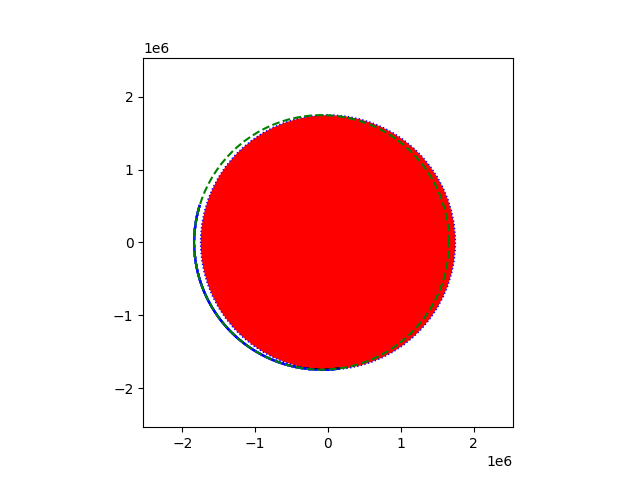

In [155]:
plotter = Plotter(env, result)

plotter.orbit_view();

In [156]:
apo = moon_radius + last_episode_result.env_h.values.max()
per = moon_radius + last_episode_result.env_h.values.min()

print(apo + per)

print(apo, per)

3574797.0513171945
1837400.0081409065 1737397.0431762883


In [130]:
print(last_episode_result.env_h.values.max())
print(last_episode_result.env_h.values.min())
print(last_episode_result.env_semi_major_axis.values[-1])
print(last_episode_result.env_eccentricity.values[-1])

# plt.figure()
# last_episode_result.env_semi_major_axis.plot.line(x="t")
# abs(last_episode_result.env_gamma_e - 0.5 * pi).plot.line(x="t")
# last_episode_result.env_gamma_e.plot.line(x="t")
# last_episode_result.env_vie_hat.plot.line(x="t")
# last_episode_result.env_h.plot.line(x="t")

191870.0650754422
8130.002112866845
1837400.0365662044
0.05000001452537267


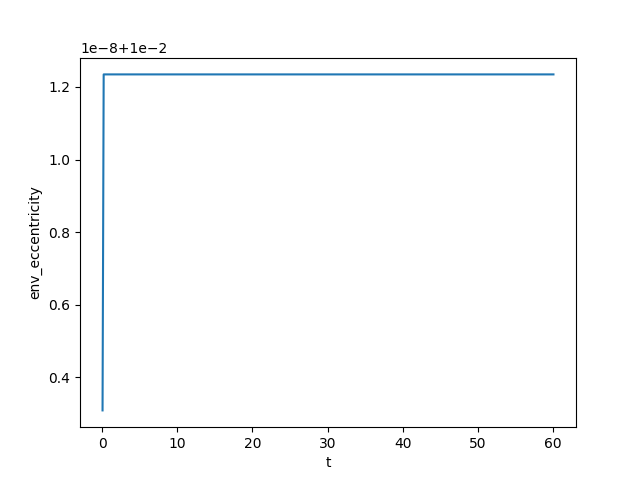

In [42]:
plt.figure()
last_episode_result.env_eccentricity.plot.line(x="t")

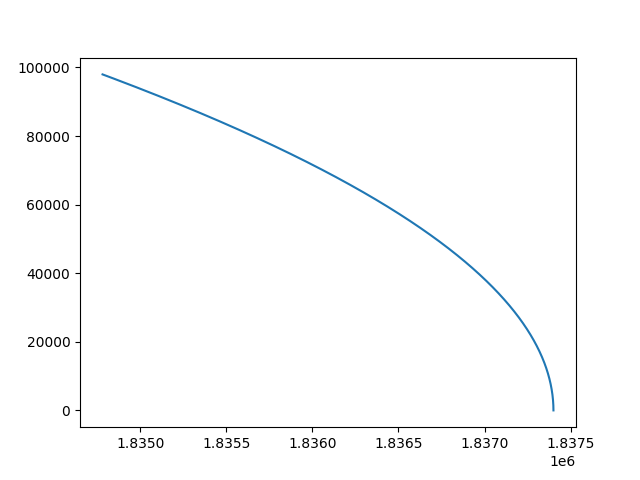

In [15]:
plt.figure()
plt.plot(last_episode_result.env_xii.values[:, 0], last_episode_result.env_xii.values[:, 1] - last_episode_result.env_xii.values[0, 1])

(-1937400.0, 1937400.0)

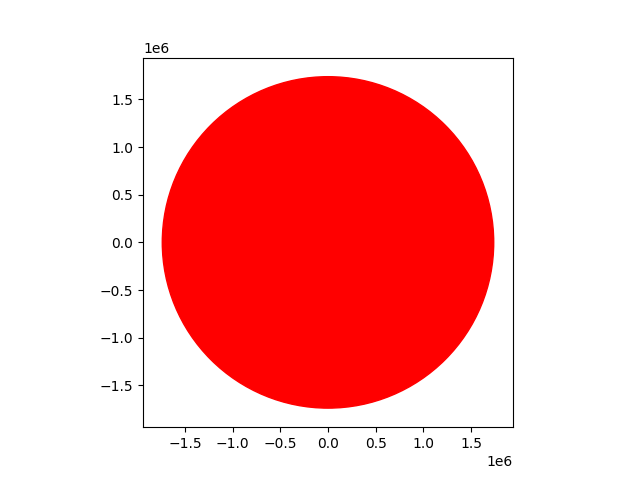

In [14]:
plt.figure()


lim_size = moon_radius + 200e3
moon = plt.Circle((0, 0), moon_radius, color='r')
ax = plt.gca()
ax.add_patch(moon)

plt.plot(last_episode_result.env_xii.values[:, 0], 
         last_episode_result.env_xii.values[:, 1])

# moon = plt.Circle((last_episode_result.env_xii.values[0, 0], last_episode_result.env_xii.values[0, 1]), moon_radius/ 10, color='b')
# ax = plt.gca()
# ax.add_patch(moon)

ax.set_aspect('equal')
plt.xlim([-lim_size, lim_size])
plt.ylim([-lim_size, lim_size])

In [15]:
env.reset()

array([0.       , 1.5707964, 0.99999  , 0.       , 0.       , 1.       ],
      dtype=float32)

In [16]:
a = pi * 0.5

env.sim.step((
    True,
    False,
    nb.int32(1),
    nb.float64(pi * 0.4),
))
env.sim_states_dict()

{'t': '0.05',
 'action_engine_on': 'True',
 'action_drop_stage': 'False',
 'action_autopilot_mode': '1',
 'action_autopilot_reference': '1.2566370614359172',
 'ap_comm_gamma_e': 'nan',
 'ap_comm_theta_e': 'nan',
 'gii': '[-9.94965859e-17 -1.62490256e+00]',
 'xii': '[1.06385129e-10 1.73740100e+06]',
 'vii': '[5.70157870e-18 9.31138464e-02]',
 'aii': '[1.14041062e-16 1.86243188e+00]',
 'tei': '[[-1.000000e+00  6.123234e-17]\n [ 6.123234e-17  1.000000e+00]]',
 'vie': '[1.54074396e-33 9.31138464e-02]',
 'fii_thrust': '[4.16379912e-16 6.80000000e+00]',
 'theta_i': '1.5707963267948966',
 'theta_i_dot': '0.0',
 'theta_e': '1.5707963267948966',
 'mass': '1.9499133537206932',
 'mass_dot': '-0.0017329255861365954',
 'h': '1.0',
 'engine_on': 'True',
 'stage_state': '1',
 'stage_idx': '0',
 'stage_ignitions_left': '-2',
 'gamma_i': '1.5707963267948966',
 'gamma_e': '1.5707963267948966',
 'longitude': '1.5707963267948966',
 'reward': '0.0',
 'score': '0.0',
 'done': 'False'}